<a href="https://colab.research.google.com/github/emaudealtema/Computer_vision_repo/blob/main/Uqar_Final_Project_EfficientNet_Model_100_epochs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from fastai.vision import *
from fastai import *
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pandas as pd

In [3]:
df = pd.read_csv("/content/drive/MyDrive/UCMerced/multilabels.txt", sep="\t")
df.tail()

,IMAGE\LABEL,airplane,bare-soil,buildings,cars,chaparral,court,dock,field,grass,mobile-home,pavement,sand,sea,ship,tanks,trees,water
2095,tenniscourt95,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0
2096,tenniscourt96,0,1,1,1,0,1,0,0,1,0,1,0,0,0,0,1,0
2097,tenniscourt97,0,1,1,1,0,1,0,0,1,0,1,0,0,0,0,1,0
2098,tenniscourt98,0,1,1,1,0,1,0,0,1,0,1,0,0,0,0,1,0
2099,tenniscourt99,0,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,0


In [4]:
df.shape

(2100, 18)

In [5]:
class_count = pd.DataFrame(df.sum(axis=0)).reset_index()
class_count.columns = ["class", "Count"]
class_count.drop(class_count.index[0], inplace=True)
class_count

,class,Count
1,airplane,100
2,bare-soil,718
3,buildings,691
4,cars,886
5,chaparral,115
6,court,105
7,dock,100
8,field,103
9,grass,975
10,mobile-home,102


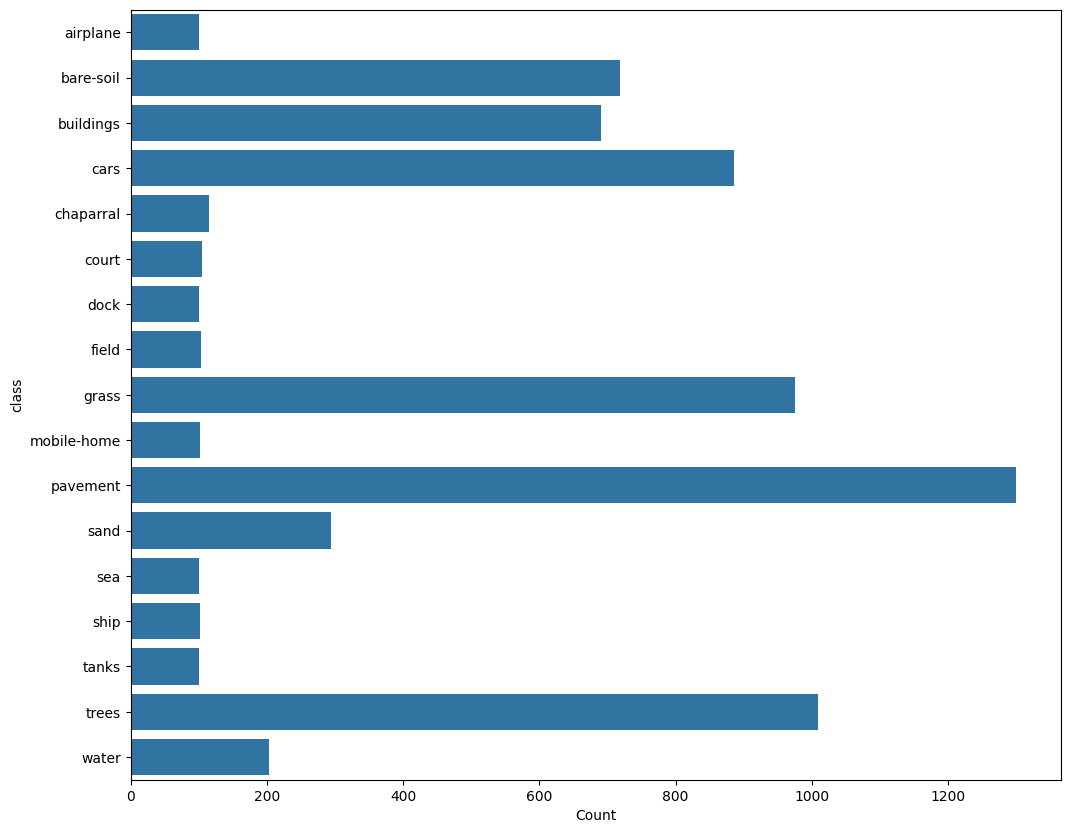

In [6]:
fig, ax= plt.subplots(figsize=(12,10))
sns.barplot(y="class", x="Count",  data=class_count, ax=ax);

In [7]:
list(class_count['class'])

['airplane',
 'bare-soil',
 'buildings',
 'cars',
 'chaparral',
 'court',
 'dock',
 'field',
 'grass',
 'mobile-home',
 'pavement',
 'sand',
 'sea',
 'ship',
 'tanks',
 'trees',
 'water']

In [8]:
# Fait plus haut
from fastai.vision.all import *
import pandas as pd

In [9]:
path = Path('/content/drive/MyDrive/UCMerced')
df = pd.read_csv("/content/drive/MyDrive/UCMerced/multilabels.txt", sep="\t")

In [10]:
df.head()

,IMAGE\LABEL,airplane,bare-soil,buildings,cars,chaparral,court,dock,field,grass,mobile-home,pavement,sand,sea,ship,tanks,trees,water
0,agricultural00,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1,agricultural01,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,agricultural02,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,agricultural03,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,agricultural04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [11]:
label_cols = df.columns[1:]  # toutes les colonnes sauf IMAGE\LABEL

def get_labels(row):
    return [label for label in label_cols if row[label] == 1]

In [12]:
df['labels'] = df.apply(get_labels, axis=1)

In [13]:
df[['IMAGE\\LABEL', 'labels']].head()

,IMAGE\LABEL,labels
0,agricultural00,"[field, trees]"
1,agricultural01,[field]
2,agricultural02,[field]
3,agricultural03,[field]
4,agricultural04,[trees]


In [14]:
def get_x(row):
    img_name = row['IMAGE\\LABEL']
    folder = img_name[:-2]  # agricultural00 → agricultural
    return path/'Images'/folder/f'{img_name}.tif'

In [15]:
# Construction du datablock multi-label
dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_x=get_x,
    get_y=ColReader('labels'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(224),
    batch_tfms=aug_transforms()
)

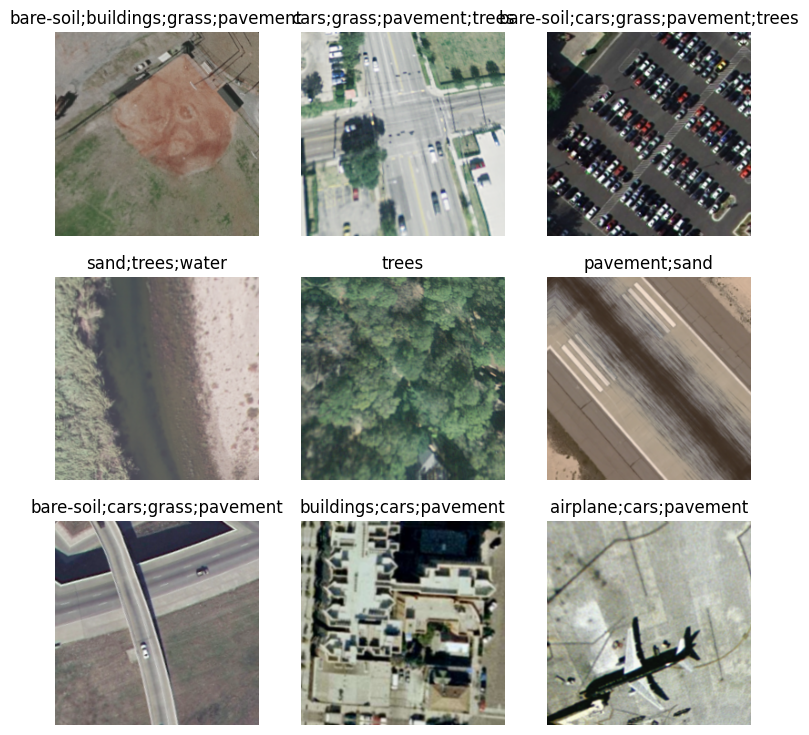

In [16]:
dls = dblock.dataloaders(df, bs=32)
dls.show_batch()

In [17]:
# Charger le Model Efficientnet
learn = vision_learner(
    dls,
    'efficientnet_b0',
    loss_func=BCEWithLogitsLossFlat(),
    metrics=accuracy_multi
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

<div></div>

SuggestedLRs(valley=0.001737800776027143)

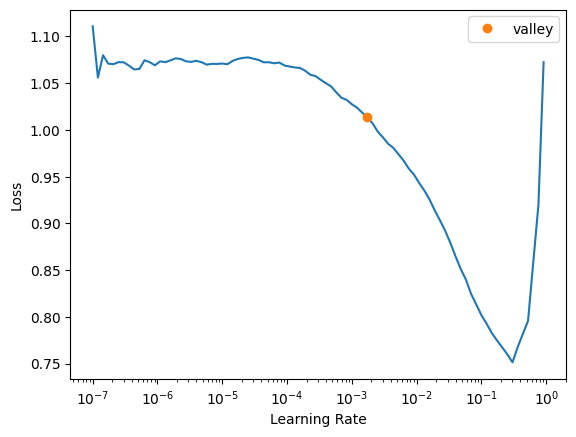

In [18]:
# Find le Learning Rate
learn.lr_find()

In [19]:
# Entrainement du modele
learn.fine_tune(100, base_lr=1e-1)

epoch,train_loss,valid_loss,accuracy_multi,time
0,0.427873,0.345210,0.897339,00:16


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.231416,0.152782,0.939216,00:02
1,0.167476,0.124104,0.949160,00:02
2,0.137827,0.114254,0.951541,00:02
3,0.112247,0.117679,0.949720,00:02
4,0.101029,0.117574,0.949019,00:02
5,0.090882,0.113759,0.955882,00:02
6,0.087746,0.112222,0.957983,00:02
7,0.078208,0.126143,0.953642,00:02
8,0.075072,0.118864,0.953782,00:02
9,0.071158,0.125855,0.955602,00:02


In [21]:
# Les metriques avancées
from fastai.metrics import PrecisionMulti, RecallMulti, F1ScoreMulti

learn.metrics = [
    accuracy_multi,
    PrecisionMulti(),
    RecallMulti(),
    F1ScoreMulti()
]

In [27]:
!wget https://www.dropbox.com/s/6tt0t61uq2w1n3s/test.zip
!unzip test.zip

--2026-05-05 11:25:21--  https://www.dropbox.com/s/6tt0t61uq2w1n3s/test.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/3c1r3xm1z8q225hqhuf7h/test.zip?rlkey=3xqce3ujgj3iw992z31dszc00 [following]
--2026-05-05 11:25:22--  https://www.dropbox.com/scl/fi/3c1r3xm1z8q225hqhuf7h/test.zip?rlkey=3xqce3ujgj3iw992z31dszc00
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc421a81815297268289a4d0c23b.dl.dropboxusercontent.com/cd/0/inline/C_5BzunUQJwwybjpUOjYhVOFVF5DnkJT0eqPB_q2xvxmp7PBwdKQaIpte1anc_PRuCGgwK8iYHf6OPoUvrmazIP3FpXfwyJOzXCz4L_iYv40qiySuZOwTnmJc7nrOTmCjIMxCNg9ciH0XXULCbmpqbQa/file# [following]
--2026-05-05 11:25:22--  https://uc421a81815297268289a4d0c23b.dl.dropboxusercontent.com/cd/0/inline/C_5BzunUQJww

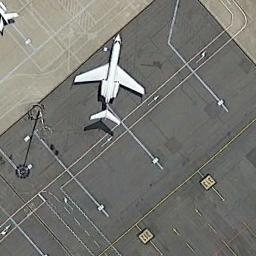

In [30]:
img =  PILImage.create("/content/test/airplane_439.jpg")
img

In [31]:
pred,_,probs = learn.predict(img)

print(pred)

['airplane', 'pavement']


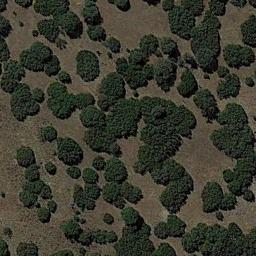

In [32]:
img =  PILImage.create("/content/test/chaparral_121.jpg")
img

In [33]:
pred,_,probs = learn.predict(img)

print(pred)

['bare-soil', 'trees']


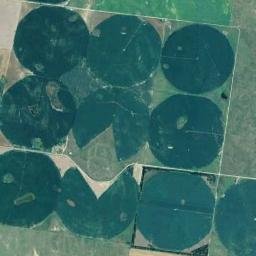

In [34]:
img =  PILImage.create("/content/test/circular_farmland_006.jpg")
img

In [36]:
pred,_,probs = learn.predict(img)

print(pred)

[]


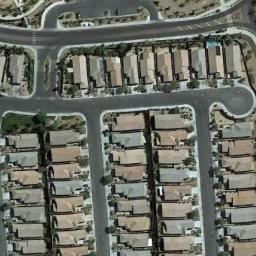

In [37]:
img =  PILImage.create("/content/test/dense_residential_025.jpg")
img

In [38]:
pred,_,probs = learn.predict(img)

print(pred)

['cars', 'grass', 'mobile-home', 'pavement']


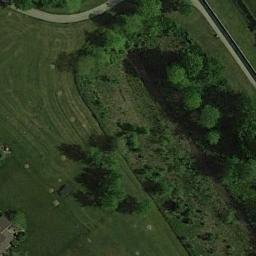

In [39]:
img =  PILImage.create("/content/test/meadow_028.jpg")
img

In [40]:
pred,_,probs = learn.predict(img)

print(pred)

['grass', 'pavement', 'trees']


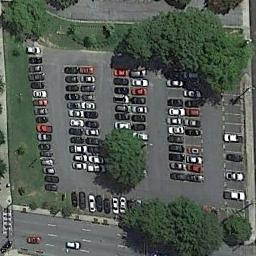

In [41]:
img =  PILImage.create("/content/test/parking_lot_032.jpg")
img

In [42]:
pred,_,probs = learn.predict(img)

print(pred)

['cars', 'grass', 'pavement', 'trees']


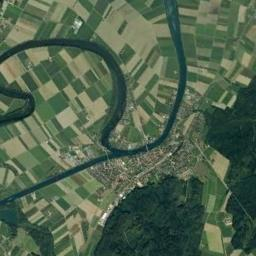

In [43]:
img =  PILImage.create("/content/test/river_209.jpg")
img

In [44]:
pred,_,probs = learn.predict(img)

print(pred)

['grass']


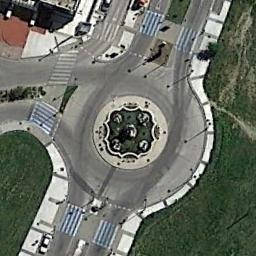

In [45]:
img =  PILImage.create("/content/test/roundabout_086.jpg")
img

In [46]:
pred,_,probs = learn.predict(img)

print(pred)

['buildings', 'cars', 'grass', 'pavement', 'trees']


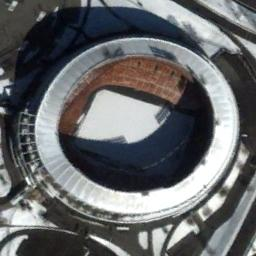

In [47]:
img =  PILImage.create("/content/test/stadium_040.jpg")
img

In [48]:
pred,_,probs = learn.predict(img)

print(pred)

['bare-soil', 'grass', 'pavement', 'tanks']


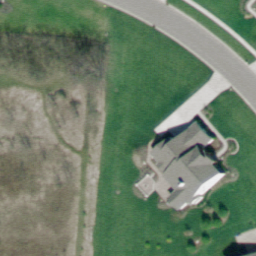

In [57]:
img =  PILImage.create("/content/drive/MyDrive/UCMerced/Images/sparseresidential/sparseresidential54.tif")
img

In [58]:
pred,_,probs = learn.predict(img)

print(pred)

['bare-soil', 'buildings', 'grass', 'pavement']


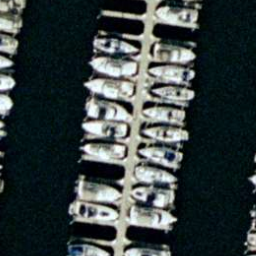

In [59]:
img =  PILImage.create("/content/drive/MyDrive/UCMerced/Images/harbor/harbor23.tif")
img

In [60]:
pred,_,probs = learn.predict(img)

print(pred)

['dock', 'ship', 'water']


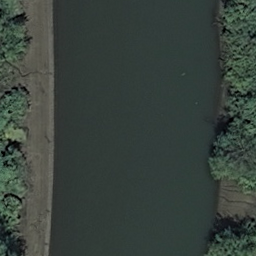

In [61]:
img =  PILImage.create("/content/drive/MyDrive/UCMerced/Images/river/river99.tif")
img


In [62]:
pred,_,probs = learn.predict(img)

print(pred)

['grass', 'trees', 'water']


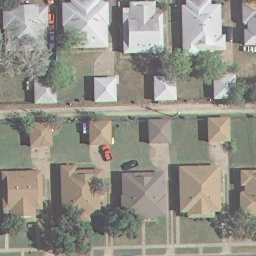

In [63]:
img =  PILImage.create("/content/drive/MyDrive/UCMerced/Images/mediumresidential/mediumresidential06.tif")
img

In [64]:
pred,_,probs = learn.predict(img)

print(pred)

['buildings', 'cars', 'grass', 'pavement', 'trees']


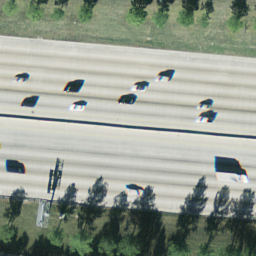

In [65]:
img =  PILImage.create("/content/drive/MyDrive/UCMerced/Images/freeway/freeway73.tif")
img

In [66]:
pred,_,probs = learn.predict(img)

print(pred)

['cars', 'grass', 'pavement', 'trees']


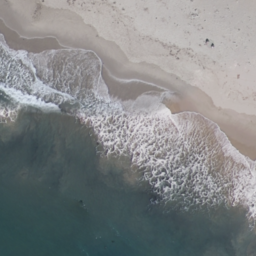

In [67]:
img =  PILImage.create("/content/drive/MyDrive/UCMerced/Images/beach/beach46.tif")
img

In [68]:
pred,_,probs = learn.predict(img)

print(pred)

['sand', 'sea']


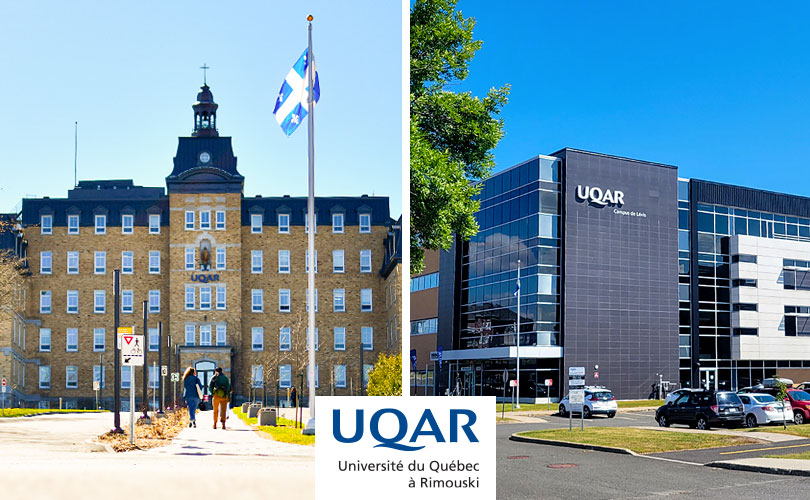

In [69]:
img =  PILImage.create("/content/drive/MyDrive/Dossier sans titre/uqar_rimouskilevis.jpg")
img

In [71]:
pred,_,probs = learn.predict(img)

print(pred)

['buildings', 'pavement', 'trees']


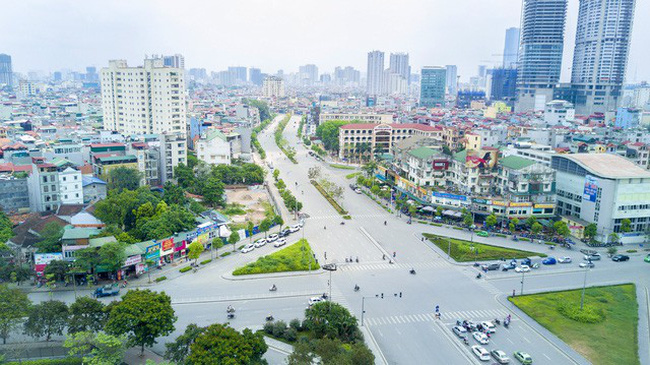

In [72]:
img =  PILImage.create("/content/drive/MyDrive/Dossier sans titre/cau giay.png")
img

In [73]:
pred,_,probs = learn.predict(img)

print(pred)

['buildings', 'cars', 'pavement', 'trees']


<Axes: >

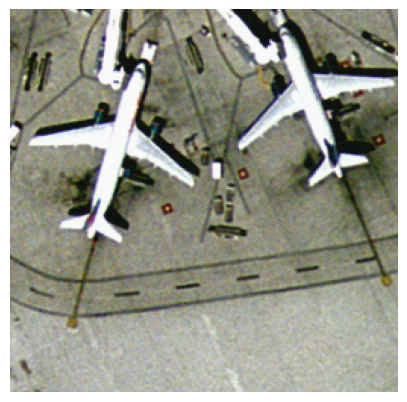

In [74]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/airplane/airplane59.tif")
img.show()

In [75]:
pred,_,probs = learn.predict(img)

print(pred)

['airplane', 'cars', 'pavement']


<Axes: >

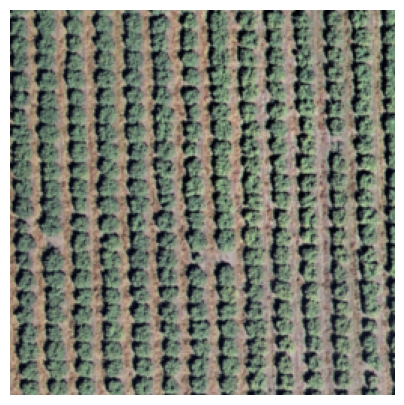

In [76]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/agricultural/agricultural22.tif")
img.show()

In [77]:
pred,_,probs = learn.predict(img)

print(pred)

['trees']


<Axes: >

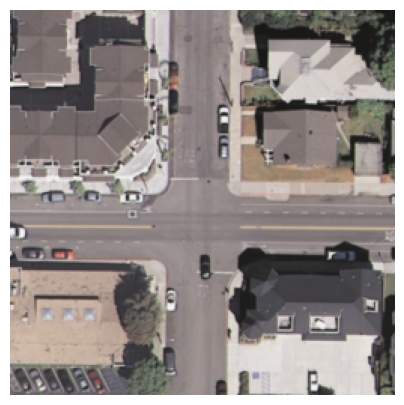

In [78]:
img = PILImage.create("/content/drive/MyDrive/UCMerced/Images/intersection/intersection98.tif")
img.show()

In [79]:
pred,_,probs = learn.predict(img)

print(pred)

['bare-soil', 'buildings', 'cars', 'pavement', 'trees']


In [80]:
# Matrice de confusion multiclae
from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# prédictions
preds, targs = learn.get_preds()

# seuil
thresh = 0.3
preds = (preds > thresh).int()

# matrice multi-label
mcm = multilabel_confusion_matrix(targs, preds)

classes = dls.vocab

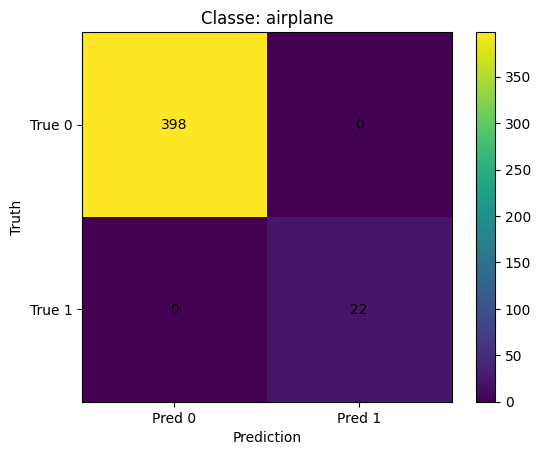

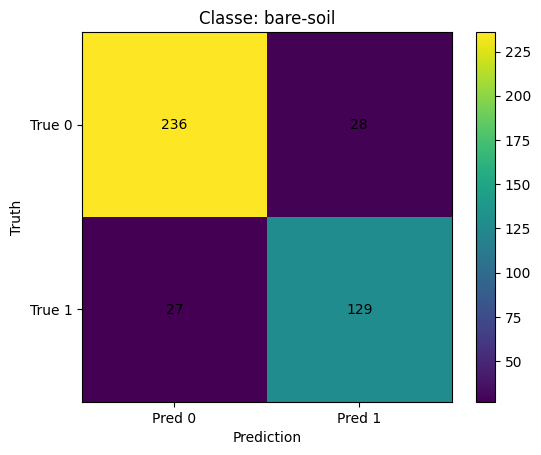

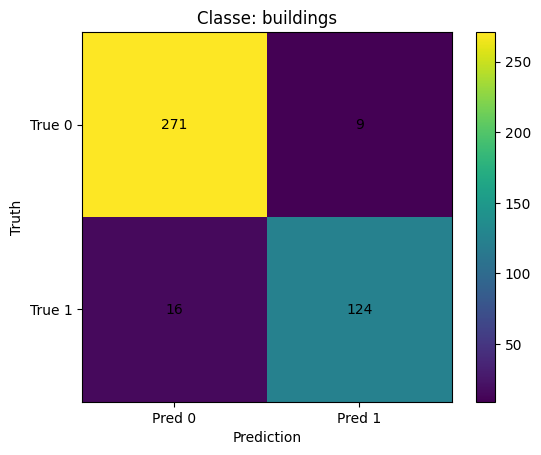

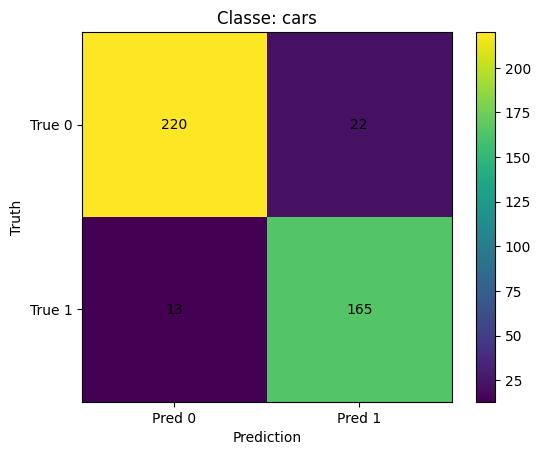

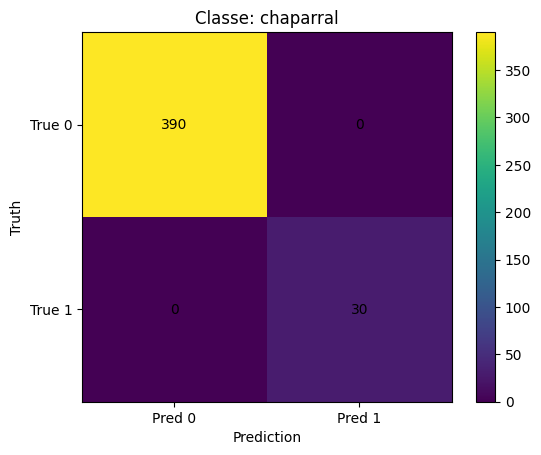

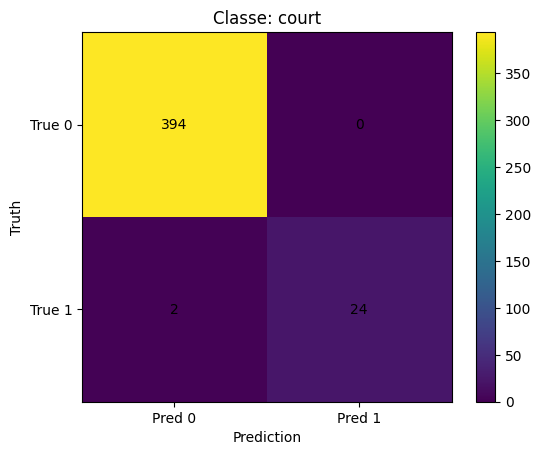

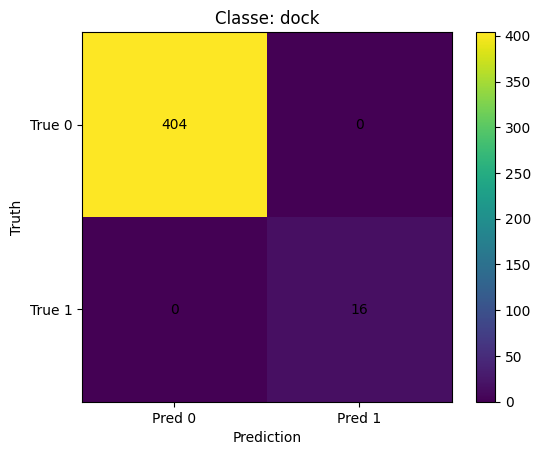

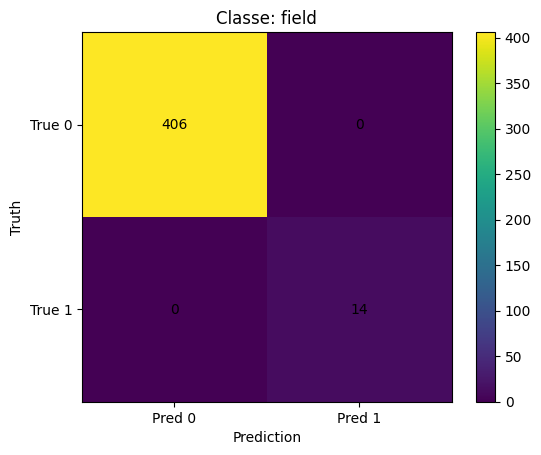

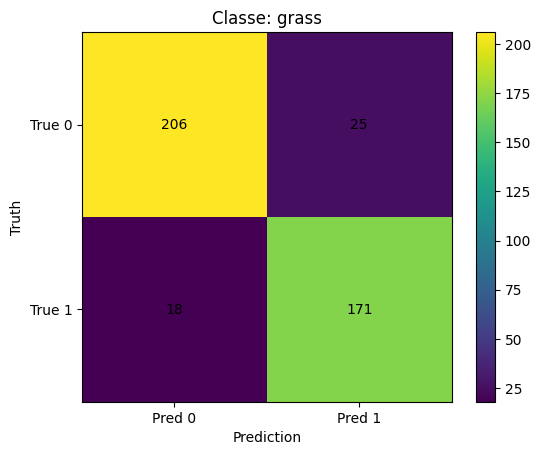

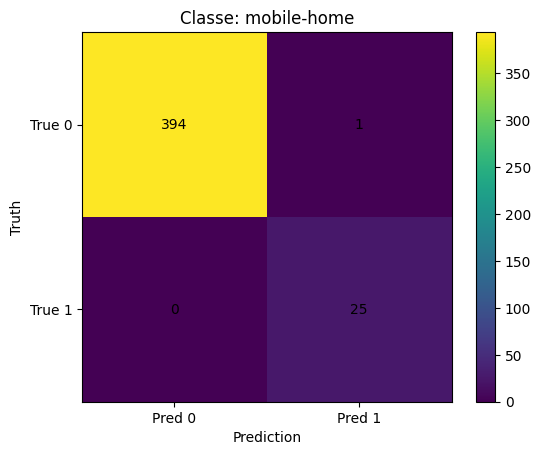

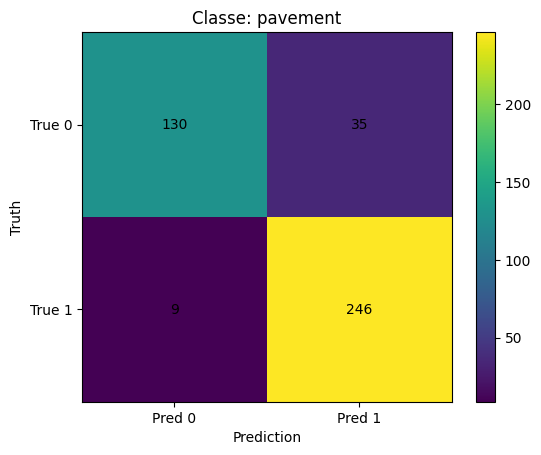

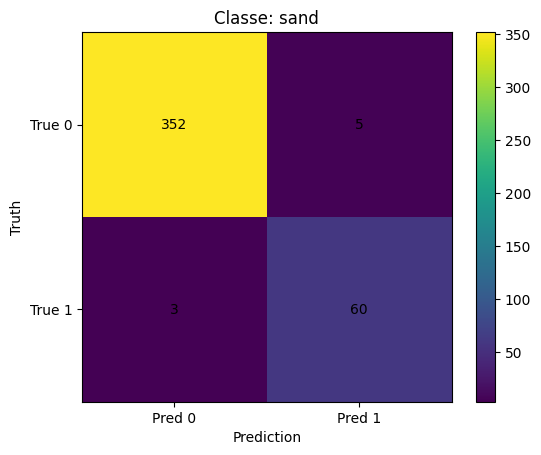

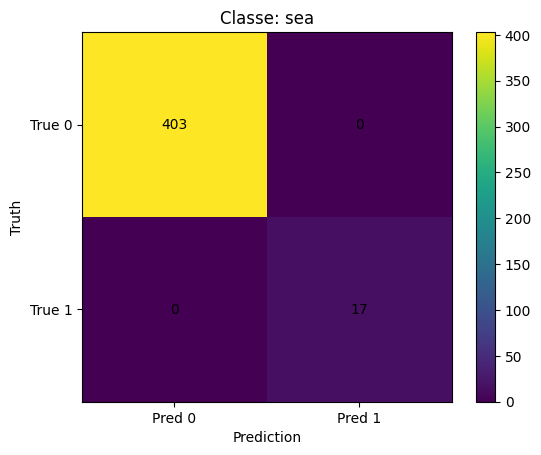

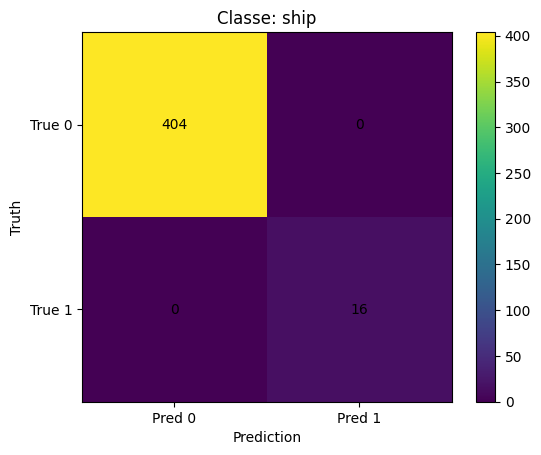

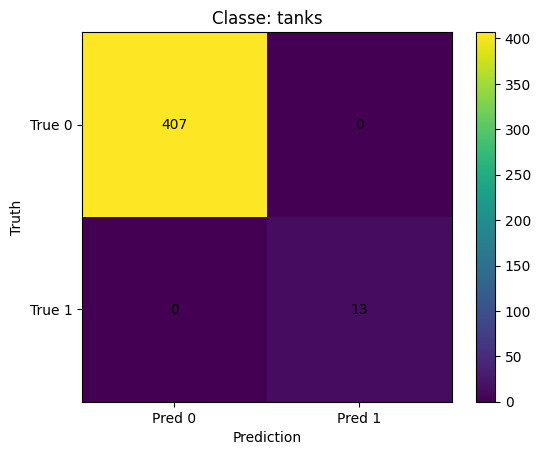

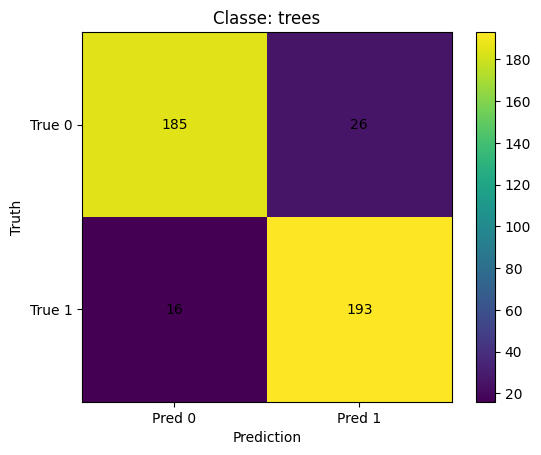

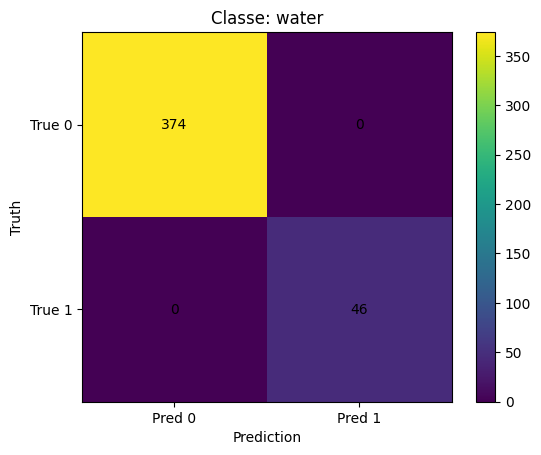

In [81]:
# Affichage de la matrice

for i, cm in enumerate(mcm):
    tn, fp, fn, tp = cm.ravel()

    plt.figure()
    plt.title(f"Classe: {classes[i]}")

    plt.imshow(cm, interpolation='nearest')
    plt.colorbar()

    plt.xticks([0,1], ['Pred 0', 'Pred 1'])
    plt.yticks([0,1], ['True 0', 'True 1'])

    plt.xlabel('Prediction')
    plt.ylabel('Truth')

    for j in range(2):
        for k in range(2):
            plt.text(k, j, cm[j, k], ha='center', va='center')

    plt.show()

In [82]:
# POur avoir une hitmap propre

from sklearn.metrics import multilabel_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

In [84]:
# Prédiction
preds, targs = learn.get_preds()

thresh = 0.3
preds_bin = (preds > thresh).int()

In [85]:
# Matrices multi-label
mcm = multilabel_confusion_matrix(targs, preds_bin)
classes = dls.vocab

In [86]:
# Fonction d'affichage
def plot_confusion_matrix(cm, class_name):
    tn, fp, fn, tp = cm.ravel()

    fig, ax = plt.subplots(figsize=(5,5))

    im = ax.imshow(cm)

    ax.set_title(f"Confusion Matrix - {class_name}", fontsize=14)
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Ground Truth")

    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(['No', 'Yes'])
    ax.set_yticklabels(['No', 'Yes'])

    # annotations
    labels = np.array([
        [f"TN\n{tn}", f"FP\n{fp}"],
        [f"FN\n{fn}", f"TP\n{tp}"]
    ])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, labels[i, j],
                    ha="center", va="center",
                    fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

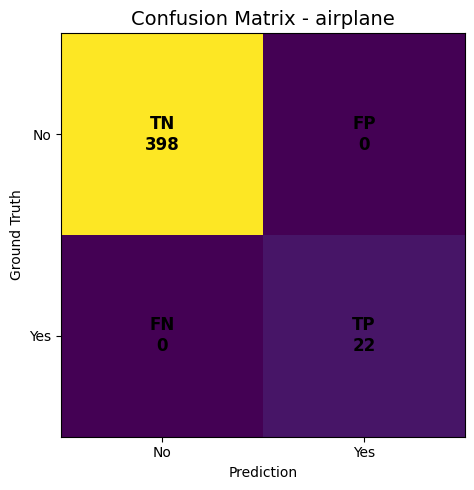

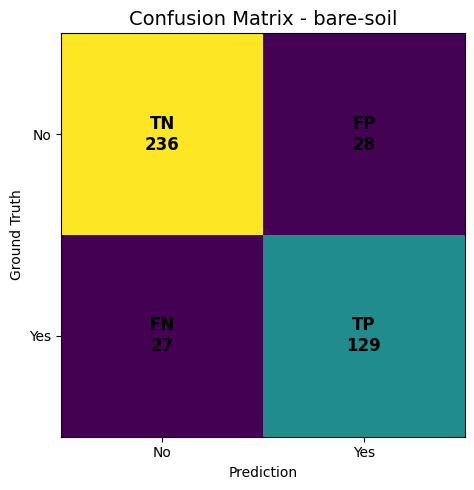

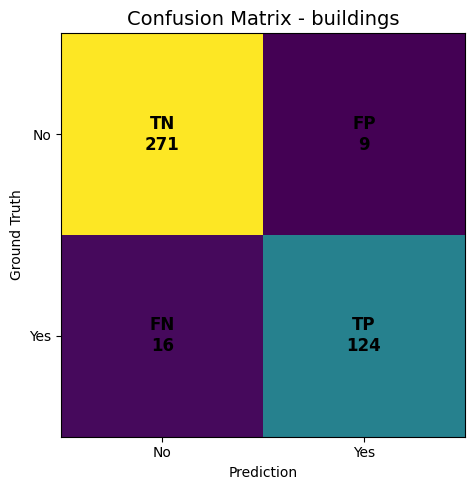

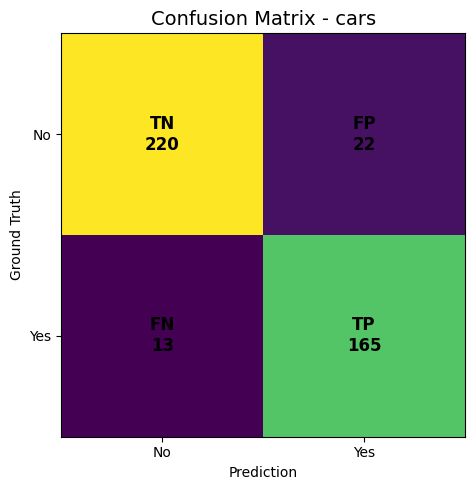

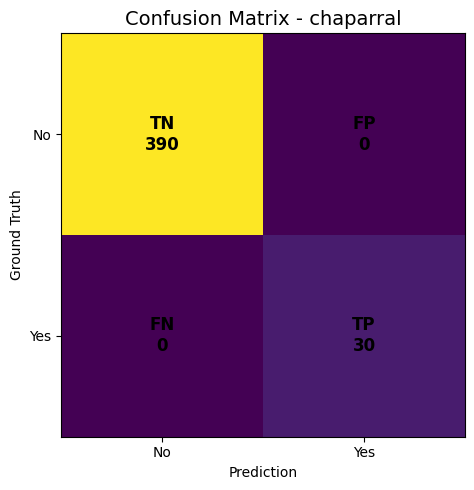

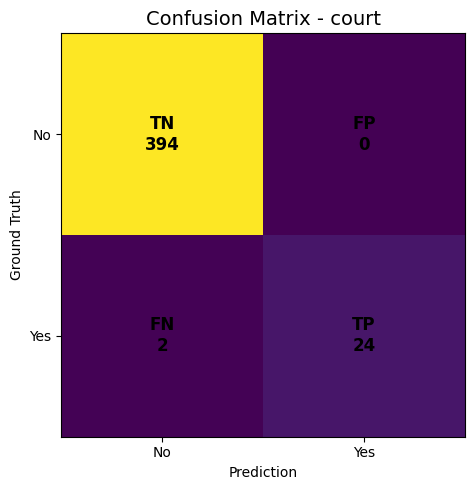

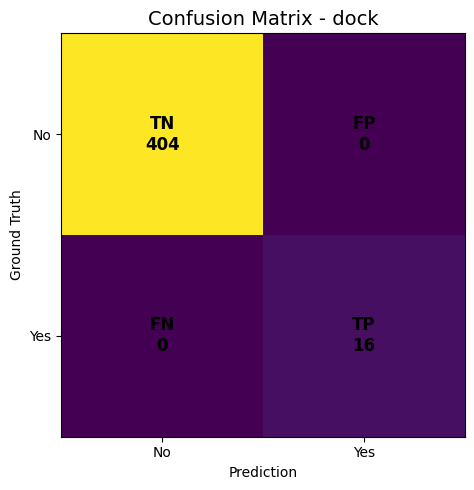

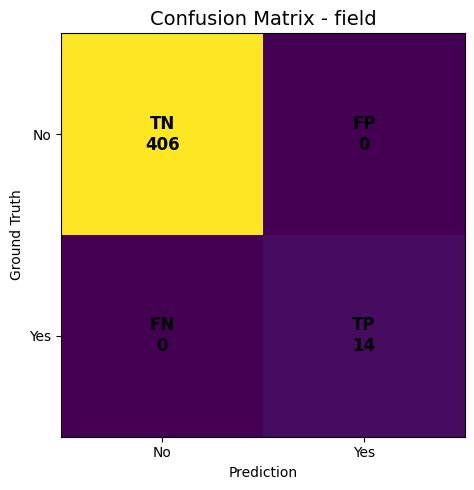

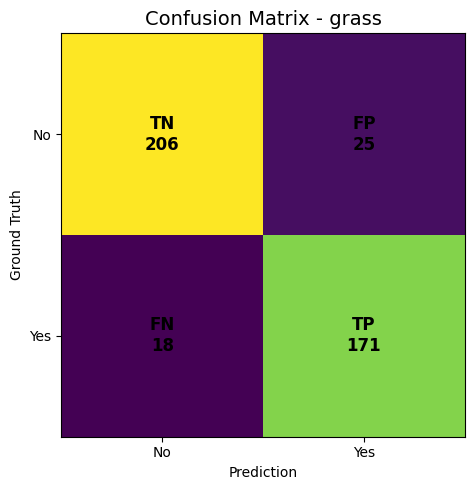

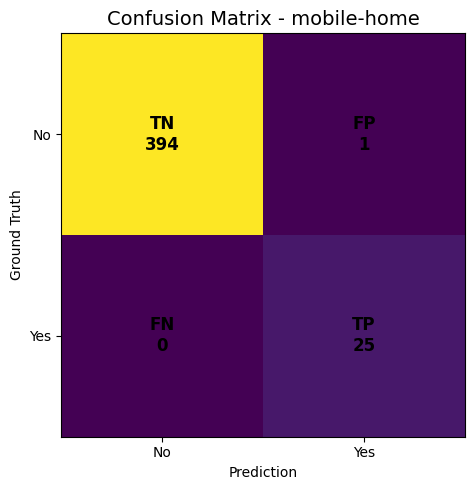

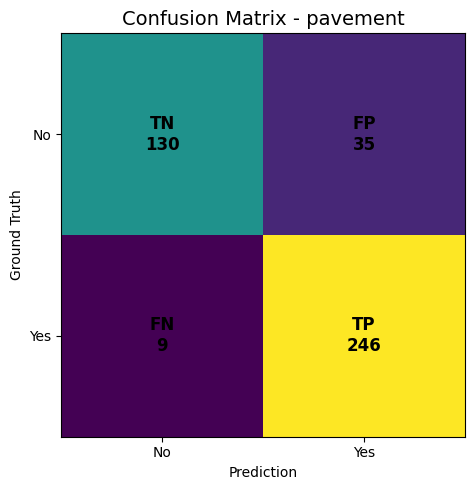

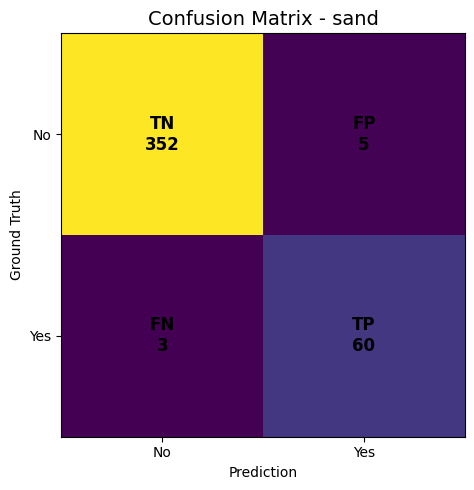

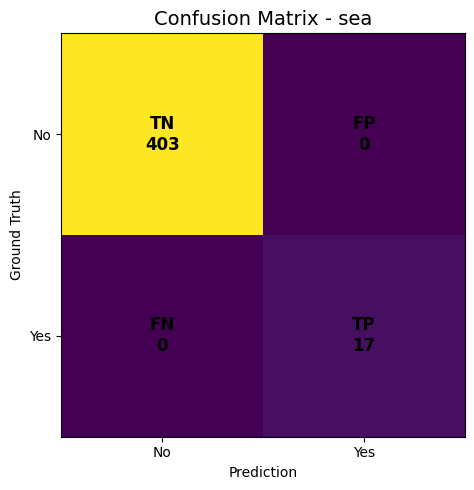

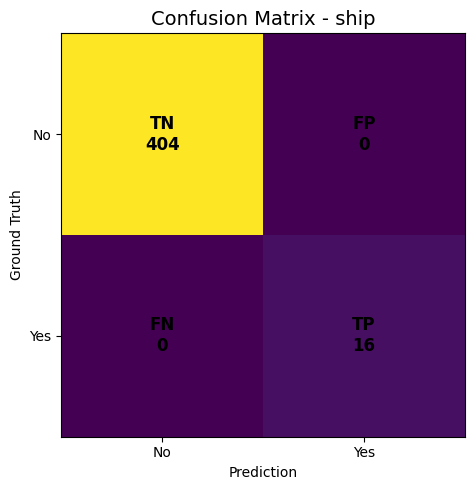

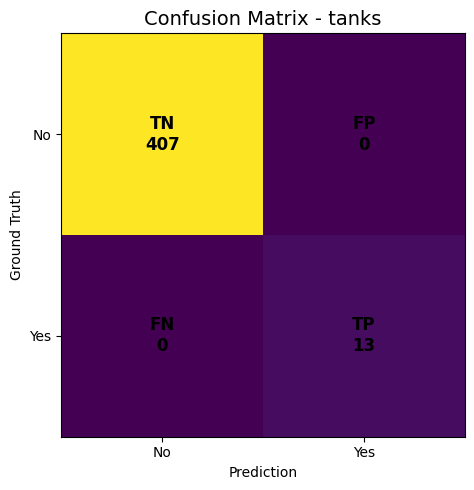

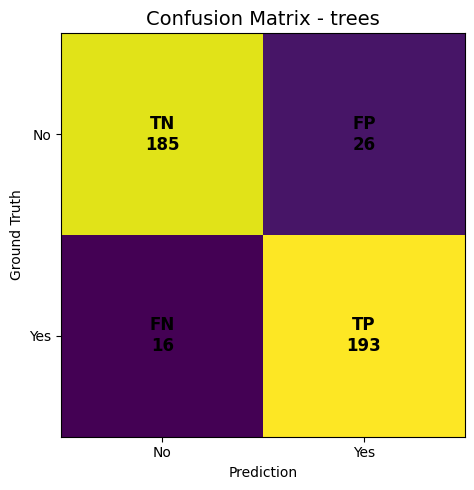

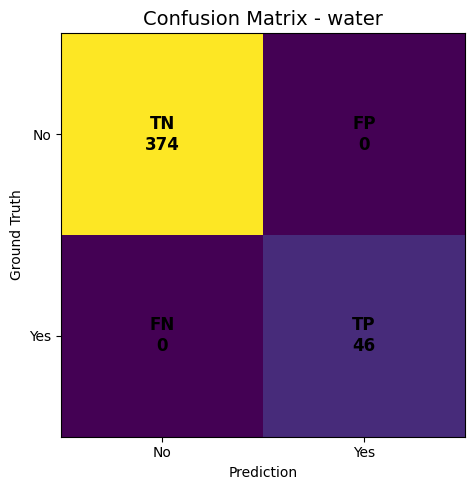

In [87]:
for i, cm in enumerate(mcm):
    plot_confusion_matrix(cm, classes[i])

In [88]:
from fastai.metrics import PrecisionMulti, RecallMulti, F1ScoreMulti

learn.metrics = [
    accuracy_multi,
    PrecisionMulti(),
    RecallMulti(),
    F1ScoreMulti()
]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,target,predicted,probabilities,loss
0,bare-soil;buildings;cars;grass;trees,buildings;grass;pavement;trees,"tensor([1.0394e-26, 2.3601e-05, 1.0000e+00, 5.5295e-11, 5.6981e-22, 1.1688e-29,\n 1.8234e-27, 2.2414e-24, 1.0000e+00, 2.3159e-27, 1.0000e+00, 4.0127e-15,\n 2.5558e-24, 2.0368e-27, 8.0816e-26, 1.0000e+00, 7.0624e-27])",3.7928502559661865
1,bare-soil;buildings;court;grass;pavement;trees,buildings;grass;pavement;trees,"tensor([1.2599e-25, 2.8037e-07, 1.0000e+00, 3.2268e-05, 2.2729e-18, 2.8765e-18,\n 1.7073e-23, 1.2205e-13, 1.0000e+00, 7.4539e-20, 1.0000e+00, 2.9731e-17,\n 7.5518e-21, 1.8662e-22, 4.6070e-18, 1.0000e+00, 2.0930e-20])",3.263561964035034
2,cars;grass;mobile-home;pavement;trees,bare-soil;cars;mobile-home;pavement;trees,"tensor([7.2116e-21, 1.0000e+00, 9.1095e-16, 1.0000e+00, 1.1658e-18, 8.2189e-22,\n 1.9824e-21, 8.9992e-19, 5.3118e-10, 1.0000e+00, 1.0000e+00, 2.0651e-17,\n 1.5917e-21, 9.1251e-19, 7.2250e-19, 1.0000e+00, 1.5807e-22])",2.848928689956665
3,bare-soil;buildings;cars;pavement;trees,bare-soil;buildings;grass;pavement;trees,"tensor([3.1186e-21, 1.0000e+00, 1.0000e+00, 1.1917e-10, 3.3661e-16, 7.5387e-19,\n 9.9845e-21, 2.9989e-12, 1.0000e+00, 3.4222e-19, 1.0000e+00, 1.0669e-06,\n 1.0743e-17, 2.2348e-20, 8.5597e-13, 1.0000e+00, 1.1957e-15])",2.727583169937134
4,buildings;court;grass;pavement;trees,bare-soil;buildings;grass;pavement;trees,"tensor([7.3989e-19, 1.0000e+00, 1.0000e+00, 1.4325e-01, 2.4864e-15, 3.6372e-15,\n 9.0238e-17, 1.3335e-13, 1.0000e+00, 7.8646e-18, 9.9998e-01, 1.5767e-10,\n 1.2444e-13, 3.0201e-16, 4.0767e-16, 1.0000e+00, 1.5094e-16])",2.714815378189087
5,buildings;court;pavement,bare-soil;buildings;court;grass;pavement;trees,"tensor([1.9439e-17, 9.5280e-01, 1.0000e+00, 3.6729e-03, 2.2638e-14, 1.0000e+00,\n 1.5990e-16, 1.0760e-15, 1.0000e+00, 2.9343e-15, 9.9996e-01, 2.6559e-15,\n 7.7596e-17, 3.1758e-14, 1.1035e-13, 1.0000e+00, 4.6617e-15])",2.5769026279449463
6,bare-soil;buildings;cars;grass,bare-soil;cars;grass;pavement,"tensor([1.1257e-17, 1.0000e+00, 5.7483e-11, 9.9948e-01, 2.6519e-14, 8.0999e-15,\n 7.7307e-17, 7.2026e-16, 1.0000e+00, 1.7279e-13, 1.0000e+00, 1.0469e-16,\n 4.4327e-16, 1.7127e-12, 1.2587e-12, 7.5419e-02, 6.7606e-17])",2.375572443008423
7,grass;pavement;trees,bare-soil;grass;pavement;sand;trees,"tensor([4.1196e-18, 1.0000e+00, 2.5898e-14, 1.5489e-09, 2.6867e-12, 4.7089e-18,\n 2.6974e-21, 5.8874e-19, 1.0000e+00, 2.0206e-21, 1.0000e+00, 1.0000e+00,\n 1.6150e-13, 1.5345e-19, 2.6118e-18, 1.0000e+00, 2.1967e-14])",2.3720996379852295
8,buildings;court;grass;pavement;sand;trees,cars;court;grass;pavement;trees,"tensor([1.2711e-17, 4.2415e-01, 8.8810e-02, 9.9831e-01, 3.8497e-15, 1.0000e+00,\n 1.0944e-16, 1.0476e-14, 1.0000e+00, 1.5384e-14, 1.0000e+00, 1.5292e-13,\n 1.7990e-14, 1.2604e-13, 1.1244e-14, 1.0000e+00, 1.2155e-15])",2.2862513065338135


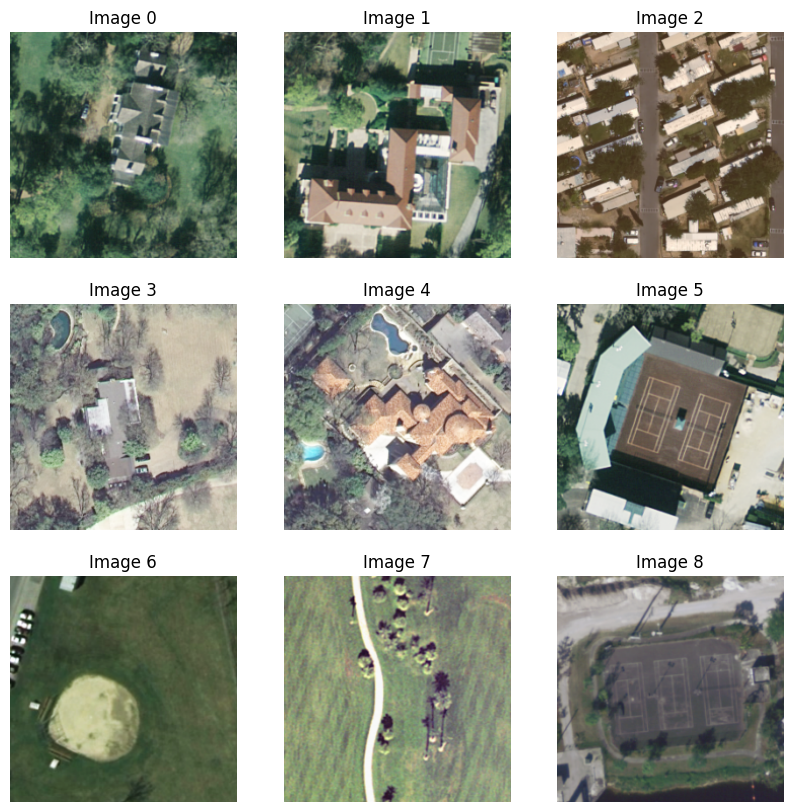

In [90]:
# Voir ou se trouve le modele
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_top_losses(9, figsize=(10,10))